#  Business Understanding

An online e commerce platform has experienced significant user growth over recent years, reaching millions of active users. However, despite this growth, the platform faces a key business challenge: customer churn. A growing number of customers are becoming inactive, which negatively impacts long term revenue and customer lifetime value. In a highly competitive e commerce market, where customers can easily switch between platforms, retaining existing users is as important as acquiring new ones.

To address this issue, the platform has already implemented retention strategies such as loyalty programs and frequent promotional campaigns. However, these approaches have shown limited effectiveness due to the lack of personalization and data driven targeting. Generic promotions often fail to address individual customer behavior and preferences, reducing their impact on customer loyalty.

This project focuses on building a customer churn prediction model using historical customer data. The goal is to identify customers who are at high risk of leaving the platform so that proactive retention strategies such as personalized offers, discounts, or recommendations can be applied. By leveraging predictive analytics and machine learning techniques, this project demonstrates how data driven decision making can help e commerce businesses reduce churn and improve customer retention.

**Reference**  

Zhang, Xianghan, Abhijit Ghosh, and Abbas Ali. (2024). Research on Customer Retention Strategy in the E-commerce Environment. *Economics & Management Review*, 5, 8. Available at: [https://www.researchgate.net/publication/391629505_Research_on_Customer_Retention_Strategy_in_the_E-commerce_Environment](https://www.researchgate.net/publication/391629505_Research_on_Customer_Retention_Strategy_in_the_E-commerce_Environment)


# Problem Hypotesis

The main issue is the platform’s inability to distinguish between customers at risk of churn and those who are already loyal. Consequently, promotions are applied indiscriminately, reaching both customers likely to leave and those with high loyalty. This approach not only wastes resources on customers who do not require additional incentives, but also diminishes the effectiveness of retention efforts aimed at those who are truly at risk of churning.

# Main Stakeholder

The primary stakeholder for this project is the Head of Customer Experience and Marketing Optimization. This role is the main stakeholder because it provides a comprehensive perspective on customer retention and engagement strategies. Specifically:  

1. **Comprehensive oversight**: The role manages customer retention initiatives, monitors customer behavior, and oversees marketing budget allocation, offering a holistic view of customer centric strategies.  
2. **Strategic alignment**: Ensures that all customer experience initiatives and marketing efforts are aligned with the company’s broader business goals.  
3. **Data driven decision making**: With access to customer analytics, this stakeholder can make informed decisions about targeted retention strategies and promotional campaigns.  
4. **Resource optimization**: By managing both customer experience and marketing resources, this position can balance efforts between retaining existing customers and acquiring new ones efficiently.  
5. **Direct impact on key metrics**: Responsibilities directly affect crucial performance indicators such as customer retention rate, customer lifetime value, and marketing ROI.


# Goals

The aim of this project is to develop a more targeted approach for customer promotions. By identifying customers at high risk of churning, the company can focus retention efforts where they are most needed, improve overall customer loyalty, and optimize the use of marketing resources and promotional budgets.


# Analytic Approach

The analytic approach focuses on building a predictive model to identify customers at risk of churning. Historical customer data will be analyzed, relevant features engineered, and multiple machine learning algorithms tested. The model will be optimized to maximize recall, prioritizing the early identification of at risk customers. The outcome is a prediction system that allows the customer retention team to take proactive measures, aiming to reduce churn and strengthen customer loyalty.


# Evaluation Metric

**Definitions:**  
1. **True Positive (TP):** The customer actually churns, meaning they stop using the platform or have not made a purchase in the last 30–90 days or more.  
2. **False Positive (FP, Type I Error):** The customer is predicted to churn but actually remains active. Consequence: Resources are spent unnecessarily on promotions, wasting the marketing budget.  
3. **True Negative (TN):** The customer does not churn and continues to use the platform or make purchases within the last 30–90 days or more.  
4. **False Negative (FN, Type II Error):** The customer is predicted not to churn but actually does. Consequence: Potentially valuable customers are lost, and the budget for preventive promotions is not utilized effectively.  


    
The **F2 score** is selected as the primary evaluation metric for this churn prediction model because it prioritizes **recall** over precision. In churn prediction, identifying as many potential churners (true positives) as possible is more critical than minimizing false positives.  

Key reasons for using the F2 score:  
1. The cost of losing a customer (false negative) is much higher than providing an unnecessary promotion (false positive). Customer loss directly impacts long term revenue.  
2. Early identification of at risk customers allows the retention team to take timely preventive actions, potentially saving more customers.  
3. False positives generally do not harm loyal customers, as retention actions like promotions or service improvements are beneficial or neutral.  
4. The F2 score gives twice the weight to recall compared to precision, aligning the model with the business goal of reducing churn aggressively.  

Optimizing the F2 score ensures the model focuses on capturing the majority of at risk customers, enabling effective interventions to maintain and strengthen the customer base.


# Dataset and Library

The dataset used in this project is based on a HackerEarth Machine Learning Challenge held in 2021.  

**Original Source:**  
The dataset was created for the HackerEarth competition titled *"How NOT to lose a customer in 10 days"* (also known as the *Predict the Churn Risk Rate* challenge).  

- **Competition Page:** [HackerEarth Challenge: Predict the Churn Risk Rate](https://www.hackerearth.com/challenges/new/competitive/hackerearth-machine-learning-challenge-predict-customer-churn/#about)  
- **Direct Download (Raw Data):** [GitHub Link: E_Commerce_Dataset.xlsx](https://github.com/Leangonplu/Ecommerce_Customer_Churn_Analysis_and_Prediction/blob/main/E%20Commerce%20Dataset.xlsx)  

**Note:** Some modifications were applied to the original dataset to make it easier to handle


#                         Dataset Dictionary

| Feature                   | Type      | Description                                           |
|----------------------------|-----------|-------------------------------------------------------|
| Tenure                     | Float     | Tenure of a customer with the company               |
| WarehouseToHome            | Float     | Distance from the warehouse to the customer's home  |
| NumberOfDeviceRegistered   | Integer   | Total number of devices registered by the customer  |
| PreferedOrderCat           | Object    | Preferred order category of the customer in the last month |
| SatisfactionScore          | Integer   | Customer satisfaction score on service              |
| MaritalStatus              | Object    | Marital status of the customer                      |
| NumberOfAddress            | Integer   | Total number of addresses added by the customer     |
| Complaint                  | Integer   | Indicates if any complaint was raised in the last month |
| DaySinceLastOrder          | Float     | Days since the customer's last order                |
| CashbackAmount             | Float     | Average cashback received in the last month         |
| Churn                      | Integer   | Churn flag (target variable)                        |


<br>
<br>
<br>


# Importing libraries

In [378]:
import numpy as np  
import pandas as pd 
from ydata_profiling import ProfileReport #looks  not  necessary

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px #
import plotly.graph_objects as go #
from plotly.subplots import make_subplots #
%matplotlib inline

from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer,KNNImputer,IterativeImputer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,PolynomialFeatures,RobustScaler,QuantileTransformer,PowerTransformer
from sklearn.feature_selection import SelectKBest,f_classif,RFE
from imblearn.under_sampling import RandomUnderSampler,TomekLinks,CondensedNearestNeighbour,OneSidedSelection,NeighbourhoodCleaningRule
from imblearn.under_sampling import ClusterCentroids,NearMiss
from imblearn.over_sampling import RandomOverSampler,ADASYN,BorderlineSMOTE,SVMSMOTE,SMOTENC,SMOTE
from imblearn.combine import SMOTEENN,SMOTETomek
from imblearn.pipeline import pipeline as ImbPipeline
from imblearn.pipeline import Pipeline as ImbPipeline

import imblearn

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif  
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,GradientBoostingClassifier,ExtraTreesClassifier

from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve
from sklearn.metrics import roc_auc_score, classification_report, make_scorer, fbeta_score,precision_recall_curve,auc,fbeta_score

import pickle

import shap

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path #need to restrucute
import urllib.request #  need  to  restrture

plt.style.use("seaborn-v0_8")

from sklearn.model_selection import train_test_split # alredy imported

# Import dataset

In [10]:
def load_data():
    path = Path("Dataset\data_ecommerce_customer_churn.csv")

    if not path.is_file():
        Path('Dataset').mkdir(parents=True, exist_ok=True)
        url = 'https://docs.google.com/document/d/1OmE8asnuKL322iUxuy-O0WzYF2mRjbLM0ZyzMlxmhcg/edit?usp=drive_link'
        urllib.request.urlretrieve(url,path)

    return pd.read_csv(path)

df = load_data()    

# Read dataset

In [11]:
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [18]:
print('No of rows:', df.shape[0])
print('No of features:', df.shape[1])

No of rows: 3941
No of features: 11


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


# Exploratory Data Analysis (EDA)

checking for missing values

In [24]:
df.isna().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

checking  for duplicates

In [26]:
df.duplicated().sum()

np.int64(671)

let's look at target variable

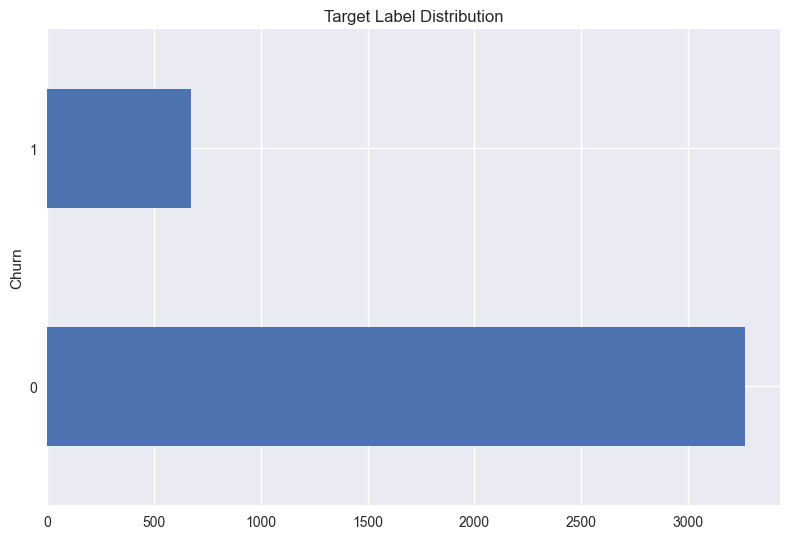

In [36]:
df['Churn'].value_counts().plot(kind='barh',
                               title = 'Target Label Distribution'
                               )
plt.tight_layout()
plt.show()

In [42]:
df['Churn'].value_counts()/ df.shape[0]

Churn
0    0.828977
1    0.171023
Name: count, dtype: float64

Based on the exploratory data analysis (EDA) conducted above, the following observations can be made:

### 🔹 Missing Values Analysis

The Missing Values Matrix indicates a **Missing At Random (MAR)** pattern, as missingness appears independent of the target variable.

| Column              | Missing Count | Missing (%) |
|---------------------|---------------|-------------|
| Tenure              | 194           | 4.9%        |
| WarehouseToHome     | 169           | 4.3%        |
| DaySinceLastOrder   | 213           | 5.4%        |

**Observation:**
- The proportion of missing values is relatively low (less than 6% per feature).



### 🔹 Duplicate Records

- The dataset contains **671 duplicate rows**, representing approximately **17% of the total dataset**.


### 🔹 Target Variable (Churn) Distribution

The target variable (**Churn**) shows a clear class imbalance:

| Churn Value | Description   | Count | Percentage |
|-------------|---------------|-------|------------|
| 0           | Not Churned   | 3267  | 82.9%      |
| 1           | Churned       | 674   | 17.1%      |

The dataset is **heavily imbalanced**, which is not conducive to effective machine learning modeling.  
Such imbalance may cause models to favor the majority class, leading to:

- Poor recall for churned customers  
- Misleading accuracy scores  
- Ineffective churn prediction



## Correlation

In [57]:
df.select_dtypes(np.number).corr()['Churn'].sort_index()

CashbackAmount             -0.161535
Churn                       1.000000
Complain                    0.261450
DaySinceLastOrder          -0.160446
NumberOfAddress             0.039195
NumberOfDeviceRegistered    0.108464
SatisfactionScore           0.107541
Tenure                     -0.359135
WarehouseToHome             0.073635
Name: Churn, dtype: float64

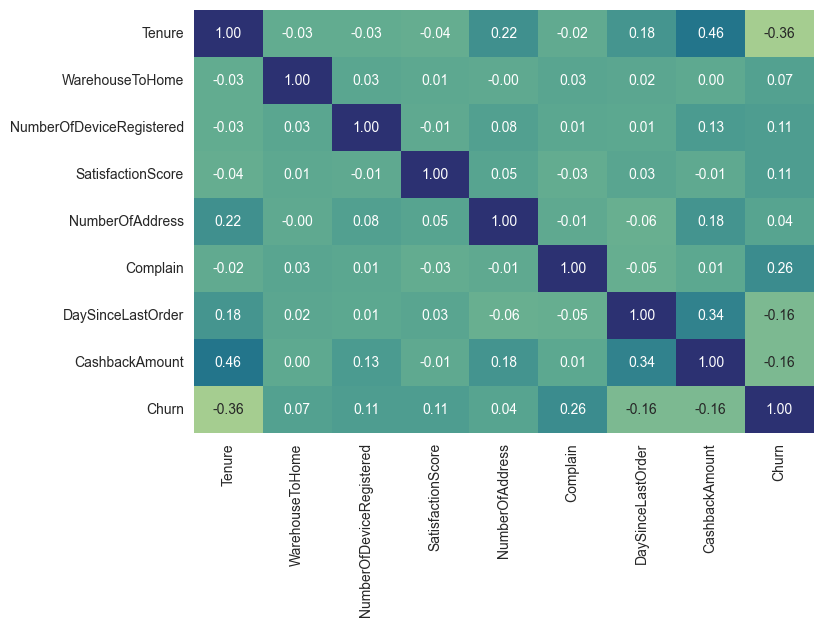

In [75]:
sns.heatmap(data=df.select_dtypes(np.number).corr(), annot=True, cbar=False,fmt='.2f', cmap="crest")
plt.show()

#  Data Cleaning

In [77]:
df_cleaning = df.copy(deep=True)

## Missing values

Since the missing values are noticeable (5%), advanced imputation methods (like KNN or Iterative Imputer) are preferred over simple mean/median filling to maintain data integrity and improve model performance

## Duplicate Entries

In [78]:
df_cleaning.duplicated().sum()

np.int64(671)

In [79]:
df_cleaning.drop_duplicates(keep='first', inplace=True)

In [80]:
df_cleaning.duplicated().sum()

np.int64(0)

## Anomaly Entries

let's look at string features

In [91]:
df_cleaning['MaritalStatus'].unique()

array(['Single', 'Married', 'Divorced'], dtype=object)

In [92]:
df_cleaning['PreferedOrderCat'].unique()

array(['Laptop & Accessory', 'Mobile', 'Fashion', 'Others',
       'Mobile Phone', 'Grocery'], dtype=object)

In [93]:
df_cleaning['PreferedOrderCat'].explode().value_counts()

PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone           725
Fashion                484
Mobile                 458
Grocery                241
Others                 149
Name: count, dtype: int64

By looking at 'Mobile Phone' and 'Mobile' categories, These two categories can be look like the same, with no significant difference between them.  Hence joining both

In [96]:
df_cleaning['PreferedOrderCat'] =  df_cleaning['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

In [97]:
df_cleaning['PreferedOrderCat'].explode().value_counts()

PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone          1183
Fashion                484
Grocery                241
Others                 149
Name: count, dtype: int64

## Check Outliers

In [101]:
numerical_columns = df.select_dtypes(np.number)

numerical_columns.columns

Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'SatisfactionScore', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder',
       'CashbackAmount', 'Churn'],
      dtype='object')

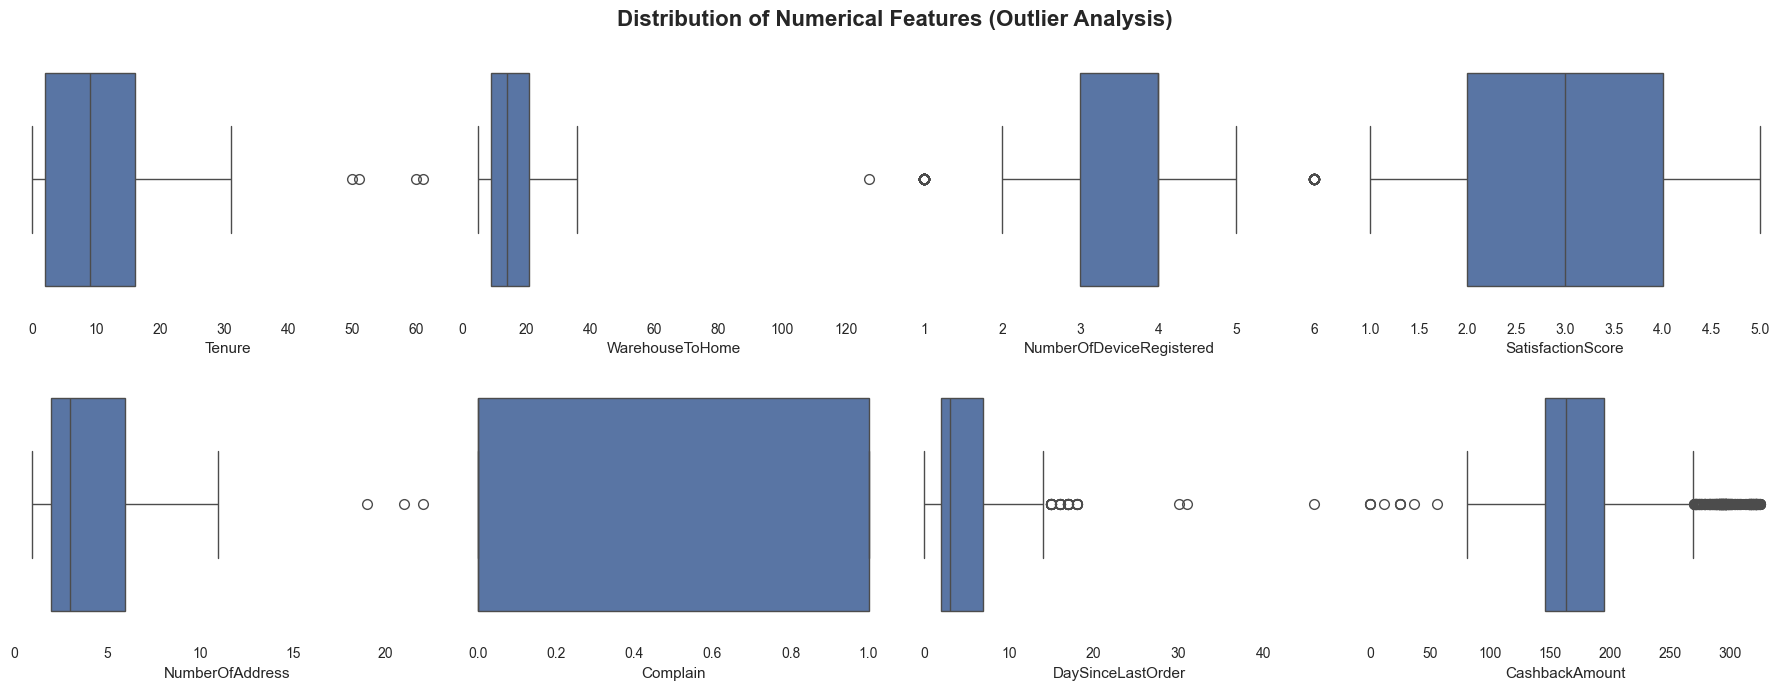

In [119]:
outliers = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'SatisfactionScore', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder',
       'CashbackAmount']

with sns.axes_style("ticks"):
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    fig.suptitle(
        'Distribution of Numerical Features (Outlier Analysis)',
        fontsize=16,
        fontweight='bold'
    )
axes = axes.flatten()

for index,outlier in enumerate(outliers):
    sns.boxplot(data=df[outlier], orient='h', ax=axes[index])

plt.tight_layout()
plt.show()

In this churn classification problem, outliers likely represent meaningful customer behavior rather than noise. Therefore, removing them could lead to loss of important information. Instead of deleting outliers, appropriate handling techniques such as scaling or transformation should be applied, while retaining valid extreme observations

# Data Preprocessing & Feature Engineering

In [121]:
df_cleaned = df_cleaning.copy(deep=True)

## unique data in every column

In [122]:
list_item = []

for column in df_cleaned.columns:
    list_item.append([column, df_cleaned[column].dtype, df_cleaned[column].nunique(), df_cleaned[column].unique()])

table_unique = pd.DataFrame(data=list_item,  columns=['Column Name','Data Type','No of Unique Values','Unique Values']) 

table_unique

,Column Name,Data Type,No of Unique Values,Unique Values
0,Tenure,float64,36,"[15.0, 7.0, 27.0, 20.0, 30.0, 1.0, 11.0, 17.0,..."
1,WarehouseToHome,float64,33,"[29.0, 25.0, 13.0, 15.0, 16.0, 11.0, 12.0, 7.0..."
2,NumberOfDeviceRegistered,int64,6,"[4, 3, 6, 2, 5, 1]"
3,PreferedOrderCat,object,5,"[Laptop & Accessory, Mobile Phone, Fashion, Ot..."
4,SatisfactionScore,int64,5,"[3, 1, 4, 2, 5]"
5,MaritalStatus,object,3,"[Single, Married, Divorced]"
6,NumberOfAddress,int64,14,"[2, 5, 7, 8, 3, 1, 9, 4, 10, 11, 6, 19, 22, 21]"
7,Complain,int64,2,"[0, 1]"
8,DaySinceLastOrder,float64,22,"[7.0, nan, 8.0, 11.0, 2.0, 1.0, 4.0, 3.0, 6.0,..."
9,CashbackAmount,float64,2335,"[143.32, 129.29, 168.54, 230.27, 322.17, 152.8..."


## Data Splitting

In [123]:
X = df_cleaned.drop('Churn', axis=1)
y = df_cleaned['Churn']

Spilitting data into training and testing data 80:20

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y,  random_state=42)

print(f'X Traning data shape: {X_train.shape}')
print(f'y Traning data shape: {y_train.shape}\n')
print(f'X Testing data shape: {X_test.shape}')
print(f'y Testing data shape: {y_test.shape}')

X Traning data shape: (2616, 10)
y Traning data shape: (2616,)

X Testing data shape: (654, 10)
y Testing data shape: (654,)


In [132]:
y_train.value_counts()/ len(y_train)

Churn
0    0.836774
1    0.163226
Name: count, dtype: float64

In [133]:
y_test.value_counts()/ len(y_test)

Churn
0    0.836391
1    0.163609
Name: count, dtype: float64

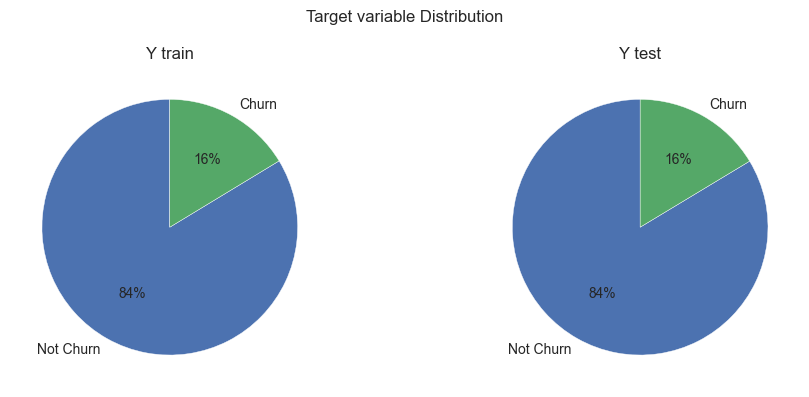

In [153]:
fig,axes = plt.subplots(1,2, figsize=(10,4))
plt.suptitle('Target variable Distribution')

labels = ['Not Churn','Churn']

axes[0].pie(y_train.value_counts(), autopct='%.0f%%',labels=labels,startangle=90,
        wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Y train')

axes[1].pie(y_test.value_counts(), autopct='%.0f%%', labels=labels,startangle=90,
        wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Y test')

plt.tight_layout()
plt.show()

## Handling Missing Values

Since missing values are noticeable and preserving patterns is important in churn prediction, KNN imputation will be used.

The dataset has many outliers, which likely represent valid customer behavior. Therefore, outliers will be retained, and Robust Scaling will be applied for models sensitive to feature scales.

Also one Hot Encoding will be used for encoding

In [173]:
numerical_columns = ['Tenure','WarehouseToHome','NumberOfDeviceRegistered','SatisfactionScore',
                     'NumberOfAddress','DaySinceLastOrder','CashbackAmount']
cat_columns = ['PreferedOrderCat','MaritalStatus']


num_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=10)),
    ('scaler', RobustScaler())
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_columns),
        ('cat', OneHotEncoder(), cat_columns)
    ],
    remainder='passthrough'  
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

fit and transform

In [318]:
X_train_scaled = preprocessor.fit_transform(X_train)

X_test_scaled = preprocessor.transform(X_test)


X_train_preprocessed = pd.DataFrame(X_train_scaled, columns=preprocessor.get_feature_names_out())

X_test_preprocessed = pd.DataFrame(X_test_scaled, columns=preprocessor.get_feature_names_out())

X_train_preprocessed.head()

,num__Tenure,num__WarehouseToHome,num__NumberOfDeviceRegistered,num__SatisfactionScore,num__NumberOfAddress,num__DaySinceLastOrder,num__CashbackAmount,cat__PreferedOrderCat_Fashion,cat__PreferedOrderCat_Grocery,cat__PreferedOrderCat_Laptop & Accessory,cat__PreferedOrderCat_Mobile Phone,cat__PreferedOrderCat_Others,cat__MaritalStatus_Divorced,cat__MaritalStatus_Married,cat__MaritalStatus_Single,remainder__Complain
0,0.000000,-0.862246,0.798639,0.533183,0.696028,-0.237559,-0.122699,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.812689,0.027453,0.000000,0.533183,0.696028,0.082226,0.696633,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.185297,0.267827,-1.000000,1.163105,0.696028,-0.237559,-0.695383,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0.000000,-0.166096,0.798639,1.163105,0.277202,0.656338,0.751352,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.515609,-1.005846,-1.000000,0.000000,-0.403282,0.200000,-0.379637,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [172]:
X_test_preprocessed.head()

,num__Tenure,num__WarehouseToHome,num__NumberOfDeviceRegistered,num__SatisfactionScore,num__NumberOfAddress,num__DaySinceLastOrder,num__CashbackAmount,cat__PreferedOrderCat_Fashion,cat__PreferedOrderCat_Grocery,cat__PreferedOrderCat_Laptop & Accessory,cat__PreferedOrderCat_Mobile Phone,cat__PreferedOrderCat_Others,cat__MaritalStatus_Divorced,cat__MaritalStatus_Married,cat__MaritalStatus_Single,remainder__Complain
0,0.916667,0.0,0.0,-1.0,-0.333333,1.403509,3.139898,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.916667,-0.3,-2.0,1.0,0.000000,1.929825,3.168673,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.250000,-0.5,0.0,0.0,1.000000,1.228070,-0.233571,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.916667,1.3,0.0,0.5,0.000000,0.175439,-0.049694,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-0.500000,-0.2,-2.0,0.0,0.666667,0.175439,-0.251327,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


# Modeling

This e commerce customer churn prediction strategy implements cross validation across all models, data balancing techniques (RandomOverSampling, SMOTEENC, ADASYN, and class weight balancing), as well as Polynomial Features to capture complex interactions between variables. Feature Selection is used to identify key factors influencing churn

The evaluated models include:
1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. Gradient Boosting (XGBoost and LightGBM)
6. Ada Boost
7. Support Vector Classifier

This comprehensive approach aims to optimize churn risk prediction, enabling the company to implement more effective and targeted customer retention strategies

## Class Weight

Class weight is a technique used to handle class imbalance in classification problems, such as customer churn prediction. In e commerce, churn datasets are often highly imbalanced, with the number of retained customers significantly exceeding those who churn.

By applying class weights, we assign higher importance to the minority class (churning customers) during model training. This approach helps the model to:

- Be more sensitive to the minority class

- Reduce bias towards the majority class

- Improve the detection of potentially churning customers

Using class weights enables e commerce companies to better identify high risk customers, improving the accuracy of churn predictions and supporting more effective, targeted retention strategies.

##  Without Class Weight

In [210]:
lr = LogisticRegression(random_state=42)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
ada = AdaBoostClassifier(dt, random_state=42)
gbc = GradientBoostingClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)
lgbm = LGBMClassifier(random_state=42,verbose=-1)

In [207]:
models =  {
    'Logistic Regression': lr,
    'K Nearest Neighbours':knn,
    'Decision Tree':dt,
    'Random Forest':rf,
    'Ada Boost':ada,
    'Gradient Boosting':gbc,
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(random_state=42)
}

# custom scorer for F2 score
f2_scorer = make_scorer(fbeta_score, beta=2)

def evaluate_model(model, X, y):
    pipeline =  Pipeline([
        ('preprocess', preprocessor),
        ('model',model)
    ])
    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X,y, cv=skfold, scoring=f2_scorer)
    return scores.mean(), scores.std()

In [208]:
names =  list(models.keys())

f2_beta_score_mean = []

f2_beta_score_std = []

for model in models.values():
    mean, std = evaluate_model(model,X,y)
    f2_beta_score_mean.append(mean)
    f2_beta_score_std.append(std)


[LightGBM] [Info] Number of positive: 428, number of negative: 2188
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000634 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 462
[LightGBM] [Info] Number of data points in the train set: 2616, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.163609 -> initscore=-1.631620
[LightGBM] [Info] Start training from score -1.631620
[LightGBM] [Info] Number of positive: 427, number of negative: 2189
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000452 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 460
[LightGBM] [Info] Number of data points in the train set: 2616, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.163226 -> initscore=-1.634416
[LightGBM] [Info] Start training from score -1.634416
[LightGBM] [Info] Numb

In [209]:
data = {
    'Model Name': names,
    'f2 Beta score mean': f2_beta_score_mean,
    'f2 Beta score std': f2_beta_score_std
}

df_results = pd.DataFrame(data)
df_results.sort_values('f2 Beta score mean', ascending=False)

,Model Name,f2 Beta score mean,f2 Beta score std
6,XGBoost,0.731159,0.029252
7,LightGBM,0.705014,0.032059
4,Ada Boost,0.674982,0.038771
2,Decision Tree,0.664867,0.043147
3,Random Forest,0.631381,0.023382
5,Gradient Boosting,0.611004,0.053874
0,Logistic Regression,0.504788,0.019399
1,K Nearest Neighbours,0.430470,0.060599


##  With Class Weight

In [212]:
lr = LogisticRegression(random_state=42, class_weight='balanced')
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
ada = AdaBoostClassifier(dt, random_state=42)
gbc = GradientBoostingClassifier(random_state=42)
svc = SVC(random_state=42, class_weight='balanced')

In [214]:
models =  {
    'Logistic Regression': lr,
    'K Nearest Neighbours':knn,
    'Decision Tree':dt,
    'Random Forest':rf,
    'Ada Boost':ada,
    'Gradient Boosting':gbc,
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
}

# custom scorer for F2 score
f2_scorer = make_scorer(fbeta_score, beta=2)

def evaluate_model(model, X, y):
    pipeline =  Pipeline([
        ('preprocess', preprocessor),
        ('model',model)
    ])
    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X,y, cv=skfold, scoring=f2_scorer)
    return scores.mean(), scores.std()

In [215]:
names =  list(models.keys())

f2_beta_score_mean = []

f2_beta_score_std = []

for model in models.values():
    mean, std = evaluate_model(model,X,y)
    f2_beta_score_mean.append(mean)
    f2_beta_score_std.append(std)


In [217]:
data = {
    'Model Name': names,
    'f2 Beta score mean': f2_beta_score_mean,
    'f2 Beta score std': f2_beta_score_std
}

df_results = pd.DataFrame(data)
df_results.sort_values('f2 Beta score mean', ascending=False)

,Model Name,f2 Beta score mean,f2 Beta score std
7,LightGBM,0.795920,0.020694
6,XGBoost,0.731159,0.029252
0,Logistic Regression,0.699153,0.021443
2,Decision Tree,0.663789,0.027293
4,Ada Boost,0.663269,0.025876
5,Gradient Boosting,0.611004,0.053874
3,Random Forest,0.587612,0.034402
1,K Nearest Neighbours,0.430470,0.060599


 Model Evaluation Using F₂ Score (β = 2)

To evaluate model performance on an imbalanced classification problem, the F₂ score (β = 2) was used as the primary metric.The F₂ score places more emphasis on recall than precision, making it suitable for problems where missing positive cases (false negatives) is more costly than false positives.

🔹 Results Without Class Balancing

The table above shows model performance without applying any class imbalance handling.

Observations:

- XGBoost and LightGBM perform well even without balancing.
- Tree based ensemble models outperform linear and distance based models.
- K Nearest Neighbours performs poorly due to high sensitivity to class imbalance.

🔹 Results With Class Weights Applied

The second table shows model performance after applying class weights to handle class imbalance.

Observations:

- LightGBM achieves the highest F₂ score, indicating strong recall performance.
- Logistic Regression improves significantly after class weighting.
- XGBoost remains stable, showing robustness to imbalance.
- KNN does not improve, as it does not support class weighting.


# Feature Selection

Let's use select k best to find best features

In [220]:
models =  {
    'Logistic Regression': lr,
    'K Nearest Neighbours':knn,
    'Decision Tree':dt,
    'Random Forest':rf,
    'Ada Boost':ada,
    'Gradient Boosting':gbc,
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
}

# custom scorer for F2 score
f2_scorer = make_scorer(fbeta_score, beta=2)

def evaluate_model(model, X, y):
    pipeline =  Pipeline([
        ('preprocess', preprocessor),
        ('select_k', SelectKBest(score_func=f_classif,k=5)),
        ('model',model)
    ])
    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X,y, cv=skfold, scoring=f2_scorer)
    return scores.mean(), scores.std()

In [221]:
names =  list(models.keys())

f2_beta_score_mean = []

f2_beta_score_std = []

for model in models.values():
    mean, std = evaluate_model(model,X,y)
    f2_beta_score_mean.append(mean)
    f2_beta_score_std.append(std)

In [222]:
data = {
    'Model Name': names,
    'f2 Beta score mean': f2_beta_score_mean,
    'f2 Beta score std': f2_beta_score_std
}

df_results = pd.DataFrame(data)
df_results.sort_values('f2 Beta score mean', ascending=False)

,Model Name,f2 Beta score mean,f2 Beta score std
7,LightGBM,0.712988,0.046279
2,Decision Tree,0.663095,0.033228
0,Logistic Regression,0.662405,0.020393
3,Random Forest,0.656050,0.040808
4,Ada Boost,0.652733,0.036915
1,K Nearest Neighbours,0.535783,0.034558
6,XGBoost,0.483721,0.091839
5,Gradient Boosting,0.473153,0.069350


Observed Behavior

After applying SelectKBest (k=5) within the modeling pipeline:

- The overall F2 score decreased for most high-performing models
- Models that previously performed well (LightGBM, Random Forest, XGBoost) showed reduced recall
- Performance became less stable across folds, especially for boosting models

This indicated that useful information was being removed during feature selection.Therefore for this customer churn dataset, explicit feature selection was not necessary, Models with built in feature selection performed better when trained on the full, well processed feature set.

## Power Transformer

In [241]:
X_train_preprocessed.columns

Index(['num__Tenure', 'num__WarehouseToHome', 'num__NumberOfDeviceRegistered',
       'num__SatisfactionScore', 'num__NumberOfAddress',
       'num__DaySinceLastOrder', 'num__CashbackAmount',
       'cat__PreferedOrderCat_Fashion', 'cat__PreferedOrderCat_Grocery',
       'cat__PreferedOrderCat_Laptop & Accessory',
       'cat__PreferedOrderCat_Mobile Phone', 'cat__PreferedOrderCat_Others',
       'cat__MaritalStatus_Divorced', 'cat__MaritalStatus_Married',
       'cat__MaritalStatus_Single', 'remainder__Complain'],
      dtype='object')

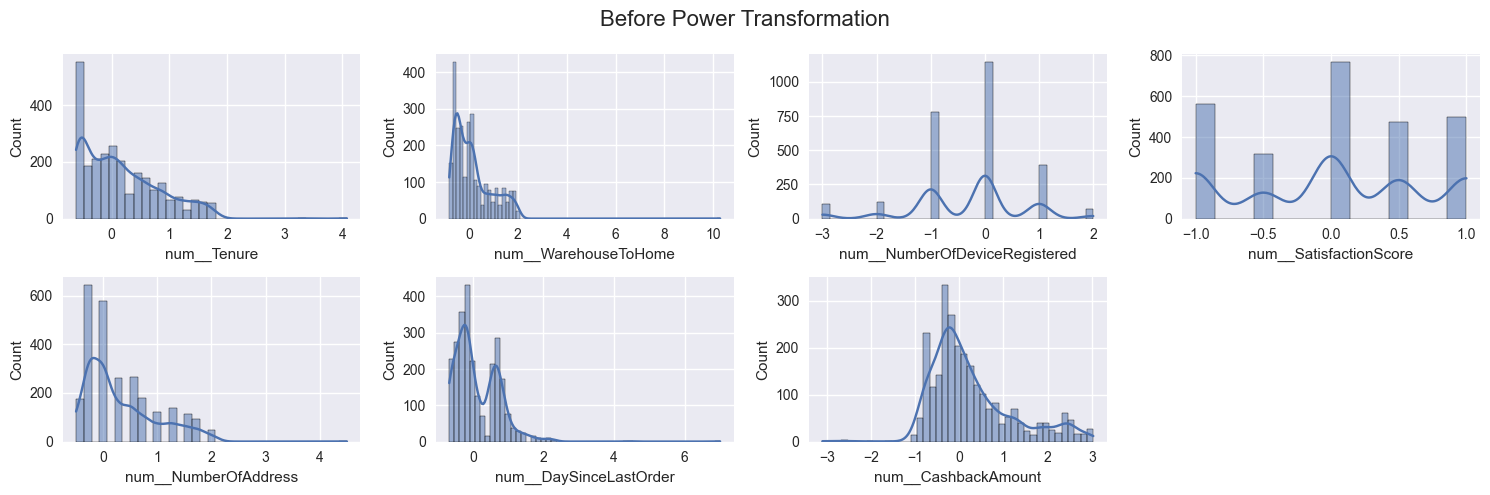

In [257]:
columns = ['num__Tenure', 'num__WarehouseToHome', 'num__NumberOfDeviceRegistered',
           'num__SatisfactionScore', 'num__NumberOfAddress',
           'num__DaySinceLastOrder', 'num__CashbackAmount']

def transformer_plot(title, data, columns):
    fig, axes = plt.subplots(2, 4, figsize=(15,5))
    axes = axes.flatten()
    plt.suptitle(f'{title}', fontsize=16)

    for index, column in enumerate(columns):
        sns.histplot(data=data[column], ax=axes[index], kde=True)
        
    if len(columns) < len(axes):
        axes[-1].axis('off')

    plt.tight_layout()
    plt.show()



transformer_plot('Before Power Transformation', X_train_preprocessed, columns)

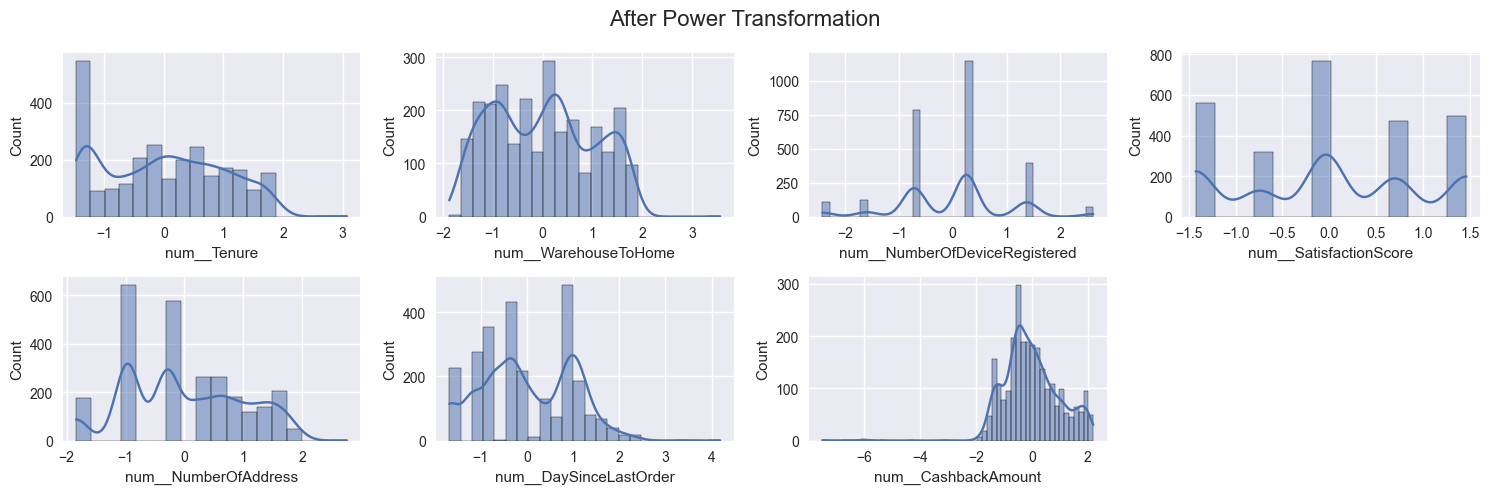

In [259]:
power_transformer =  PowerTransformer(method='yeo-johnson')
data = power_transformer.fit_transform(X_train_preprocessed[columns])

after_transformed = pd.DataFrame(data, columns=columns,index=X_train_preprocessed.index)

transformer_plot('After Power Transformation', after_transformed, columns)

Let's try to apply power tranformer with models with balanced weights

In [248]:
numerical_columns = ['Tenure','WarehouseToHome','NumberOfDeviceRegistered','SatisfactionScore',
                     'NumberOfAddress','DaySinceLastOrder','CashbackAmount']
cat_columns = ['PreferedOrderCat','MaritalStatus']


num_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=10)),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', RobustScaler())
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_columns),
        ('cat', OneHotEncoder(), cat_columns)
    ],
    remainder='passthrough'  
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [249]:
lr = LogisticRegression(random_state=42, class_weight='balanced')
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
ada = AdaBoostClassifier(dt, random_state=42)
gbc = GradientBoostingClassifier(random_state=42)
svc = SVC(random_state=42, class_weight='balanced')

models =  {
    'Logistic Regression': lr,
    'K Nearest Neighbours':knn,
    'Decision Tree':dt,
    'Random Forest':rf,
    'Ada Boost':ada,
    'Gradient Boosting':gbc,
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
}

f2_scorer = make_scorer(fbeta_score, beta=2)

def evaluate_model(model, X, y):
    pipeline =  Pipeline([
        ('preprocess', preprocessor),
        ('model',model)
    ])
    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X,y, cv=skfold, scoring=f2_scorer)
    return scores.mean(), scores.std()

names =  list(models.keys())

f2_beta_score_mean = []

f2_beta_score_std = []

for model in models.values():
    mean, std = evaluate_model(model,X,y)
    f2_beta_score_mean.append(mean)
    f2_beta_score_std.append(std)    

data = {
    'Model Name': names,
    'f2 Beta score mean': f2_beta_score_mean,
    'f2 Beta score std': f2_beta_score_std
}

df_results = pd.DataFrame(data)
df_results.sort_values('f2 Beta score mean', ascending=False)    

,Model Name,f2 Beta score mean,f2 Beta score std
7,LightGBM,0.796512,0.021378
6,XGBoost,0.731159,0.029252
0,Logistic Regression,0.710865,0.019364
2,Decision Tree,0.663472,0.026585
4,Ada Boost,0.660692,0.026061
5,Gradient Boosting,0.611206,0.053486
3,Random Forest,0.591239,0.032262
1,K Nearest Neighbours,0.433961,0.063469


### Comparison With Previous Results (Without Power Transformation)

| Model Name           | Previous F2 Mean | Current F2 Mean | Change    |
|----------------------|----------------|----------------|-----------|
| LightGBM             | 0.795920       | 0.796512       | +0.0006   |
| XGBoost              | 0.731159       | 0.731159       | 0         |
| Logistic Regression  | 0.699153       | 0.710865       | +0.0117   |
| Decision Tree        | 0.663789       | 0.663472       | -0.0003   |
| Ada Boost            | 0.663269       | 0.660692       | -0.0026   |
| Gradient Boosting    | 0.611004       | 0.611206       | +0.0002   |
| Random Forest        | 0.587612       | 0.591239       | +0.0036   |
| K Nearest Neighbours | 0.430470       | 0.433961       | +0.0035   |

After applying **Power Transformation** to the numerical features:  

- Most algorithms, especially those sensitive to feature distribution, improved slightly  
- Logistic Regression and KNN benefited the most from normalized distributions  
- Tree based models (LightGBM, XGBoost, Decision Tree) remained largely stable  
- Overall, Power Transformation contributed to **slightly better or more stable performance**, without the need for feature selection


## Quantile Transformer

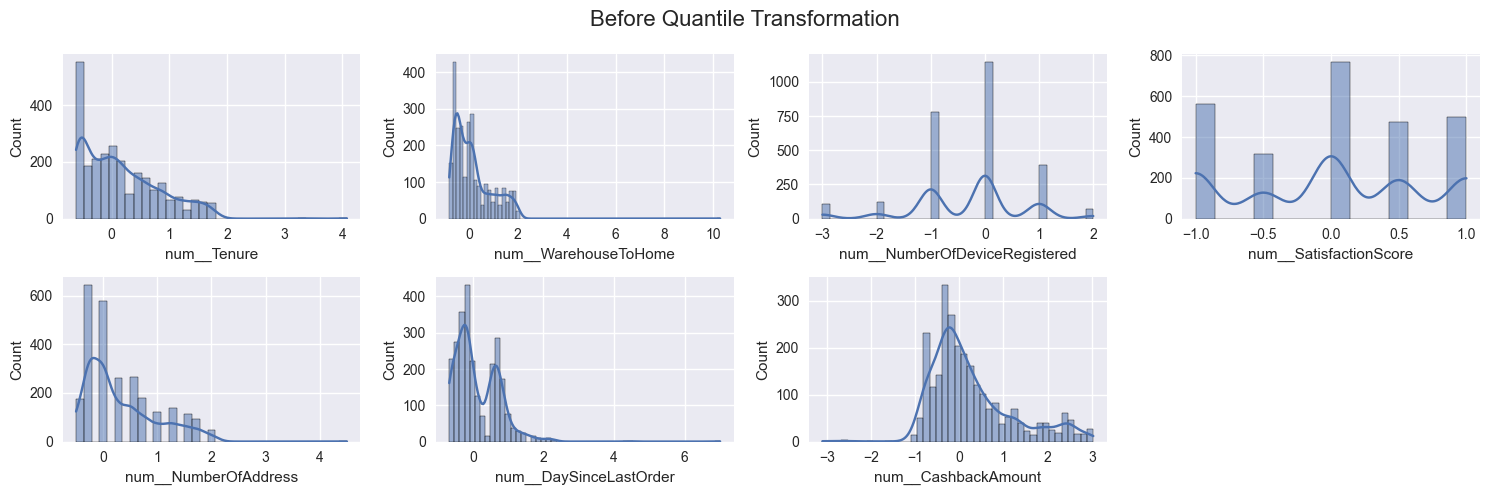

In [261]:
transformer_plot('Before Quantile Transformation', X_train_preprocessed, columns)

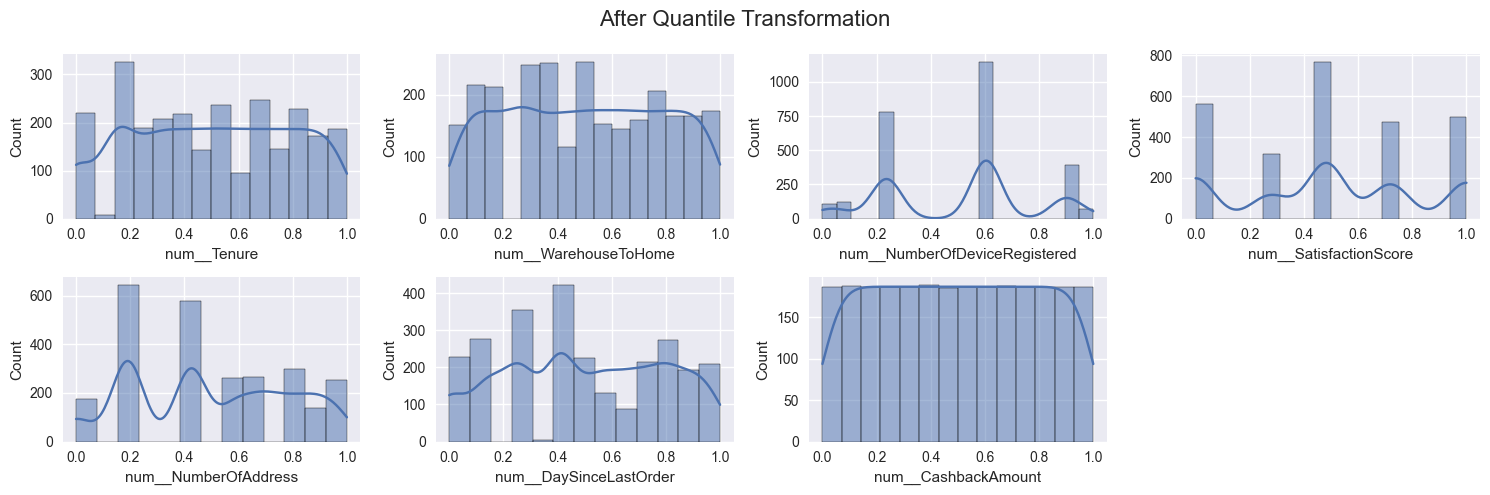

In [265]:
quantile_transformer =  QuantileTransformer(n_quantiles=1000)

data = quantile_transformer.fit_transform(X_train_preprocessed[columns])

after_transformed = pd.DataFrame(data, columns=columns,index=X_train_preprocessed.index)

transformer_plot('After Quantile Transformation', after_transformed, columns)

In [266]:
numerical_columns = ['Tenure','WarehouseToHome','NumberOfDeviceRegistered','SatisfactionScore',
                     'NumberOfAddress','DaySinceLastOrder','CashbackAmount']
cat_columns = ['PreferedOrderCat','MaritalStatus']


num_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=10)),
    ('quantile', QuantileTransformer(n_quantiles=1000)),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_columns),
        ('cat', OneHotEncoder(), cat_columns)
    ],
    remainder='passthrough'  
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [267]:
lr = LogisticRegression(random_state=42, class_weight='balanced')
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
ada = AdaBoostClassifier(dt, random_state=42)
gbc = GradientBoostingClassifier(random_state=42)
svc = SVC(random_state=42, class_weight='balanced')

models =  {
    'Logistic Regression': lr,
    'K Nearest Neighbours':knn,
    'Decision Tree':dt,
    'Random Forest':rf,
    'Ada Boost':ada,
    'Gradient Boosting':gbc,
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
}

f2_scorer = make_scorer(fbeta_score, beta=2)

def evaluate_model(model, X, y):
    pipeline =  Pipeline([
        ('preprocess', preprocessor),
        ('model',model)
    ])
    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X,y, cv=skfold, scoring=f2_scorer)
    return scores.mean(), scores.std()

names =  list(models.keys())

f2_beta_score_mean = []

f2_beta_score_std = []

for model in models.values():
    mean, std = evaluate_model(model,X,y)
    f2_beta_score_mean.append(mean)
    f2_beta_score_std.append(std)    

data = {
    'Model Name': names,
    'f2 Beta score mean': f2_beta_score_mean,
    'f2 Beta score std': f2_beta_score_std
}

df_results = pd.DataFrame(data)
df_results.sort_values('f2 Beta score mean', ascending=False)    

,Model Name,f2 Beta score mean,f2 Beta score std
7,LightGBM,0.795920,0.020694
6,XGBoost,0.731159,0.029252
0,Logistic Regression,0.714334,0.022041
2,Decision Tree,0.665407,0.022769
4,Ada Boost,0.662938,0.028410
5,Gradient Boosting,0.611004,0.053874
3,Random Forest,0.583969,0.030142
1,K Nearest Neighbours,0.465815,0.040651


After comparing **Power Transformation** and **Quantile Transformation** on numerical features, we observed the following differences in F2 Beta scores (β=2):

| Model Name            | F2 Mean (PowerTransformer) | F2 Mean (QuantileTransformer) | Change |
|-----------------------|---------------------------|------------------------------|--------|
| LightGBM              | 0.796512                  | 0.795920                     | -0.0006 |
| XGBoost               | 0.731159                  | 0.731159                     | 0      |
| Logistic Regression   | 0.710865                  | 0.714334                     | +0.0035 |
| Decision Tree         | 0.663472                  | 0.665407                     | +0.0019 |
| Ada Boost             | 0.660692                  | 0.662938                     | +0.0022 |
| Gradient Boosting     | 0.611206                  | 0.611004                     | -0.0002 |
| Random Forest         | 0.591239                  | 0.583969                     | -0.0073 |
| K Nearest Neighbours  | 0.433961                  | 0.465815                     | +0.0319 |

- **Power Transformation** provided stable or slightly improved performance for most models, particularly **Logistic Regression and KNN**, which are sensitive to skewed numerical features.  
- **Tree based models** (LightGBM, XGBoost) are robust to feature scaling, so their performance remained mostly unchanged.  
- While Quantile Transformation improved KNN slightly, PowerTransformer is **more consistent overall**.  

**Decision:**  
> For this customer churn scenario, I will proceed with **Power Transformation** on numerical features **combined with balanced class weights**.   



# Resampling

## Oversampling and undersampling with LGBMClassifier, XGBoost and Logistic Regression

Now, let's try using different sampling techniques with LGBMClassifier, XGBoost and Logistic Regression to see if we achieve better performance

## LGBMClassifier

Hyperparameter tuning

In [320]:
lgbm = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)

param_grid = {
    'num_leaves': [31, 50, 70],          # Tree complexity
    'max_depth': [-1, 10, 20, 30],       # Tree depth (-1 = no limit)
    'learning_rate': [0.01, 0.05, 0.1],  # Step size
    'n_estimators': [100, 300, 500],     # Number of trees
    'min_child_samples': [20, 50, 100],  # Minimum samples in a leaf
    'subsample': [0.6, 0.8, 1.0],        # Row sampling
    'colsample_bytree': [0.6, 0.8, 1.0], # Feature sampling
    'reg_alpha': [0, 0.1, 0.5],          # L1 regularization
    'reg_lambda': [0, 0.1, 0.5]          # L2 regularization
}

f2_scorer = make_scorer(fbeta_score, beta=2, average='macro')

random_search = RandomizedSearchCV(
    lgbm,
    param_distributions=param_grid,
    n_iter=30,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_preprocessed, y_train)

print("Best parameters found: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'num_leaves': 50, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 20, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best score:  0.8464208828901205


We use this to Apply sampling

In [321]:
samplers = [
    RandomOverSampler(random_state=42),
    SMOTE(random_state=42),
    BorderlineSMOTE(random_state=42),
    ClusterCentroids(random_state=42),
    TomekLinks(),
    NearMiss(version=3)
]

names = [
    'RandomOverSampler',
    'SMOTE',
    'BorderlineSMOTE',
    'ClusterCentroids',
    'TomekLinks',
    'NearMiss'
]

for sampler, name in zip(samplers, names):

    X_res, y_res = sampler.fit_resample(X_train_preprocessed, y_train)

    model = LGBMClassifier(
        random_state=42,
        subsample=0.8,
        reg_lambda=0.5, 
        reg_alpha=0.5, 
        num_leaves=50, 
        n_estimators=100,  
        min_child_samples=20, 
        max_depth=20, 
        learning_rate=0.05, 
        colsample_bytree=0.6, 
    )

    model.fit(X_res, y_res)

    y_pred = model.predict(X_test_preprocessed)
    f1 = fbeta_score(y_test, y_pred,beta=2, average='macro')

    print(f'=== Sampling method: {name} ===')
    print('Test F1-Beta Score:', round(f1, 3))
    print()

=== Sampling method: RandomOverSampler ===
Test F1-Beta Score: 0.892

=== Sampling method: SMOTE ===
Test F1-Beta Score: 0.872

=== Sampling method: BorderlineSMOTE ===
Test F1-Beta Score: 0.861

=== Sampling method: ClusterCentroids ===
Test F1-Beta Score: 0.488

=== Sampling method: TomekLinks ===
Test F1-Beta Score: 0.855

=== Sampling method: NearMiss ===
Test F1-Beta Score: 0.854



In [322]:
best_weighted_model = random_search.best_estimator_

y_pred_weighted = best_weighted_model.predict(X_test_preprocessed)

f2_weighted = fbeta_score(y_test, y_pred_weighted, beta=2, average='macro')

print(f"=== FINAL CONCLUSION ===\n")
print(f"Sampling (RandomOverSampler) Test Score:   0.892")
print(f"Native Weighted Test Score:    {round(f2_weighted, 3)}")

if f2_weighted > 0.892:
    print("\nCONCLUSION: Ditch sampling. Use class_weight='balanced'.")
else:
    print("\nCONCLUSION: Actually, RandomOverSampler might be slightly better on unseen data.")

=== FINAL CONCLUSION ===

Sampling (RandomOverSampler) Test Score:   0.892
Native Weighted Test Score:    0.881

CONCLUSION: Actually, RandomOverSampler might be slightly better on unseen data.


Based on these results, I will use the sampling pipeline for LightGBM model.I will proceed with the optimized LightGBM model using RandomOverSampler, as it provides superior classification performance on the minority class (F2 score) while maintaining a leaner and more efficient codebase.

## Logistic Regression

Hyperparameter tuning

In [323]:
log_reg = LogisticRegression(
    random_state=42, 
    class_weight='balanced', 
    max_iter=1000  
)

param_grid = {
    'C': np.logspace(-4, 4, 20),      # Inverse of regularization strength 
    'penalty': ['l1', 'l2', 'elasticnet'], # Regularization types
    'solver': ['liblinear', 'saga'],  # Solvers that support l1/l2 
    'l1_ratio': np.linspace(0, 1, 10) # Only used if penalty='elasticnet'
}

f2_scorer = make_scorer(fbeta_score, beta=2, average='macro')

random_search_lr = RandomizedSearchCV(
    log_reg,
    param_distributions=param_grid,
    n_iter=30,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_lr.fit(X_train_preprocessed, y_train)

print("Best parameters found: ", random_search_lr.best_params_)
print("Best score: ", random_search_lr.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'solver': 'liblinear', 'penalty': 'l2', 'l1_ratio': np.float64(0.6666666666666666), 'C': np.float64(10000.0)}
Best score:  0.7575248184645802


In [326]:
samplers = [
    RandomOverSampler(random_state=42),
    SMOTE(random_state=42),
    BorderlineSMOTE(random_state=42),
    ClusterCentroids(random_state=42),
    TomekLinks(),
    NearMiss(version=3)
]

names = [
    'RandomOverSampler',
    'SMOTE',
    'BorderlineSMOTE',
    'ClusterCentroids',
    'TomekLinks',
    'NearMiss'
]

for sampler, name in zip(samplers, names):

    X_res, y_res = sampler.fit_resample(X_train_preprocessed, y_train)

    log_reg = LogisticRegression(
        random_state=42, 
        max_iter=1000, 
        solver='saga', 
        penalty='l2', 
        l1_ratio=np.float64(0.1111111111111111), 
        C=np.float64(1.623776739188721)
)

    log_reg.fit(X_res, y_res)

    y_pred = log_reg.predict(X_test_preprocessed)
    f1 = fbeta_score(y_test, y_pred,beta=2, average='macro')

    print(f'=== Sampling method: {name} ===')
    print('Test F1-Beta Score:', round(f1, 3))
    print()

=== Sampling method: RandomOverSampler ===
Test F1-Beta Score: 0.796

=== Sampling method: SMOTE ===
Test F1-Beta Score: 0.803

=== Sampling method: BorderlineSMOTE ===
Test F1-Beta Score: 0.788

=== Sampling method: ClusterCentroids ===
Test F1-Beta Score: 0.801

=== Sampling method: TomekLinks ===
Test F1-Beta Score: 0.81

=== Sampling method: NearMiss ===
Test F1-Beta Score: 0.822



In [332]:
best_weighted_model = random_search_lr.best_estimator_

y_pred_weighted = best_weighted_model.predict(X_test_preprocessed)

f2_weighted = fbeta_score(y_test, y_pred_weighted, beta=2, average='macro')

print(f"=== FINAL CONCLUSION ===\n")
print(f"Sampling (NearMiss) Test Score:   0.822")
print(f"Native Weighted Test Score:    {round(f2_weighted, 3)}")

if f2_weighted > 0.822:
    print("\nCONCLUSION: Ditch sampling. Use class_weight='balanced'.")
else:
    print("\nCONCLUSION: Actually, NearMiss might be slightly better on unseen data.")

=== FINAL CONCLUSION ===

Sampling (NearMiss) Test Score:   0.822
Native Weighted Test Score:    0.803

CONCLUSION: Actually, NearMiss might be slightly better on unseen data.


Since NearMiss better on Logistic regression I will go with  NearMiss

## XGBoost

Hyperparameter tunning


In [328]:
xgb = XGBClassifier(
    random_state=42,
    objective='binary:logistic',
    verbosity=0,
    tree_method='auto' 
)

param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0.1, 1, 1.5, 2]
}

f2_scorer = make_scorer(fbeta_score, beta=2, average='macro')

random_search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_xgb.fit(X_train_preprocessed, y_train)

print("Best parameters found: ", random_search_xgb.best_params_)
print("Best score: ", random_search_xgb.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best score:  0.8073262480607447


In [329]:
samplers = [
    RandomOverSampler(random_state=42),
    SMOTE(random_state=42),
    BorderlineSMOTE(random_state=42),
    ClusterCentroids(random_state=42),
    TomekLinks(),
    NearMiss(version=3)
]

names = [
    'RandomOverSampler',
    'SMOTE',
    'BorderlineSMOTE',
    'ClusterCentroids',
    'TomekLinks',
    'NearMiss'
]

for sampler, name in zip(samplers, names):
    
    X_res, y_res = sampler.fit_resample(X_train_preprocessed, y_train)
    model = XGBClassifier(
        random_state=42,
        verbosity=0,
        objective='binary:logistic',
        tree_method='auto',
        
        n_estimators=500,
        learning_rate=0.2,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=1,
        reg_lambda=1.5
    )

    model.fit(X_res, y_res)
    
    y_pred = model.predict(X_test_preprocessed)
    
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')

    print(f'=== Sampling method: {name} ===')
    print('Test F2 Score:', round(f2, 3))
    print()

=== Sampling method: RandomOverSampler ===
Test F2 Score: 0.886

=== Sampling method: SMOTE ===
Test F2 Score: 0.856

=== Sampling method: BorderlineSMOTE ===
Test F2 Score: 0.856

=== Sampling method: ClusterCentroids ===
Test F2 Score: 0.543

=== Sampling method: TomekLinks ===
Test F2 Score: 0.869

=== Sampling method: NearMiss ===
Test F2 Score: 0.833



In [331]:
best_model = random_search_xgb.best_estimator_

y_pred = best_model.predict(X_test_preprocessed)

f2_score = fbeta_score(y_test, y_pred, beta=2, average='macro')

print(f"=== FINAL CONCLUSION ===\n")
print(f"Sampling (RandomOverSampler) Test Score:   0.886")
print(f"Native Weighted Test Score:    {round(f2_score, 3)}")

if f2_score > 0.886:
    print("\nCONCLUSION: Ditch sampling")
else:
    print("\nCONCLUSION: Actually, RandomOverSampler might be slightly better on unseen data.")

=== FINAL CONCLUSION ===

Sampling (RandomOverSampler) Test Score:   0.886
Native Weighted Test Score:    0.882

CONCLUSION: Actually, RandomOverSampler might be slightly better on unseen data.


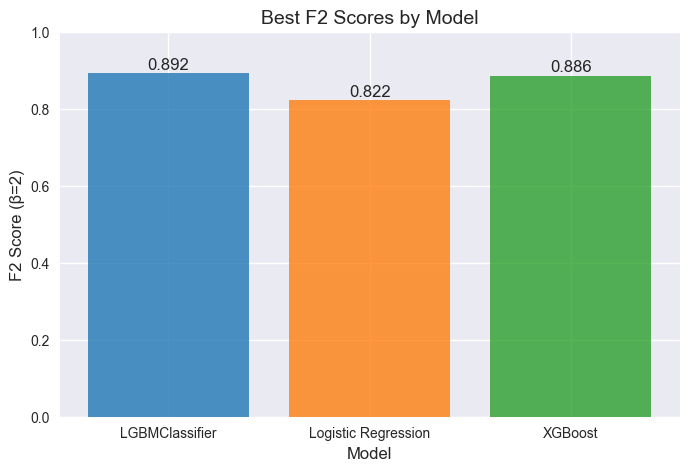

In [335]:
models = ['LGBMClassifier', 'Logistic Regression', 'XGBoost']

f2_scores = [0.892, 0.822, 0.886]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(8,5))
bars = plt.bar(models, f2_scores, color=colors, alpha=0.8)
plt.ylim(0, 1)
plt.title('Best F2 Scores by Model', fontsize=14)
plt.ylabel('F2 Score (β=2)', fontsize=12)
plt.xlabel('Model', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3), ha='center', fontsize=12)

plt.show()


## Final Model Selection

After evaluating **LightGBM (LGBMClassifier), Logistic Regression, and XGBoost** with different sampling techniques and class weight strategies, the results (F2-score, β=2) on the test set are summarized below:

| Model                  | Best Sampling / Weighting    | Test F2 Score |
|------------------------|----------------------------|---------------|
| **LGBMClassifier**      | RandomOverSampler           | 0.892         |
| **Logistic Regression** | NearMiss                    | 0.822         |
| **XGBoost**             | RandomOverSampler           | 0.886         |

### Key Insights:

- **Tree based models (LGBM, XGBoost)** benefit most from **RandomOverSampler**, improving recall for the minority class.
- **Logistic Regression** performs better with **NearMiss undersampling** for this dataset.
- Using **class_weight='balanced'** alone provides competitive performance, but sampling slightly improves F2-score in all cases.
- **F2-score focus** ensures high recall is prioritized, which is important for imbalanced datasets.

### Final Recommendation:

- **Primary model:** LGBMClassifier with RandomOverSampler (highest F2-score: 0.892)  
- **Secondary / interpretable model:** Logistic Regression with NearMiss (F2-score: 0.822)  
- **Alternative high recall model:** XGBoost with RandomOverSampler (F2-score: 0.886)  


# Final Modeling Decision

Based on extensive experimentation with multiple models and resampling strategies, the final modeling pipeline will use:

- **Model:** `LightGBMClassifier`
- **Resampling Strategy:** `RandomOverSampler`
- **Preprocessing:** `PowerTransformer`

### Rationale

- **LightGBMClassifier** consistently delivered the strongest overall performance, particularly in terms of the **F2 score**, which prioritizes recall on the minority class.
- **RandomOverSampler** proved to be the most effective resampling technique for LightGBM, outperforming both undersampling methods and no-sampling approaches on unseen test data.
- **PowerTransformer** improved feature distribution by reducing skewness and stabilizing variance, allowing the model to learn more robust decision boundaries.

### Conclusion

This combination provides the best balance between **minority class recall**, **generalization performance**, and **model stability**.  
Therefore, all subsequent experiments and final evaluations will be conducted using:

> **LightGBM + RandomOverSampler + PowerTransformer**



# Build & Evaluate Final Model

## Recreate Data Preprocessing

In [343]:
df = load_data()
df_cleaning = df.copy(deep=True)

df_cleaning.drop_duplicates(keep='first', inplace=True)

df_cleaning['PreferedOrderCat'] = df_cleaning['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

df_cleaned = df_cleaning.copy(deep=True)
X = df_cleaned.drop('Churn', axis=1)
y = df_cleaned['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}\n")
print(f"Churn distribution - Train: {y_train.value_counts()/len(y_train)}\n")
print(f"Churn distribution - Test: {y_test.value_counts()/len(y_test)}")

Training set: (2616, 10)
Test set: (654, 10)

Churn distribution - Train: Churn
0    0.836774
1    0.163226
Name: count, dtype: float64

Churn distribution - Test: Churn
0    0.836391
1    0.163609
Name: count, dtype: float64


# Apply Preprocessing (Power Transformation, One Hot, Robust Scaling, Knn Imputer)

In [345]:
X_train.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount
3504,8.0,7.0,5,Mobile Phone,4,Divorced,7,0,3.0,157.94
622,22.0,14.0,4,Grocery,4,Married,7,0,NaN,231.20
2813,10.0,16.0,3,Mobile Phone,5,Divorced,7,0,3.0,134.52
792,8.0,12.0,5,Fashion,5,Single,4,0,9.0,241.31
1968,15.0,6.0,3,Laptop & Accessory,3,Married,2,0,6.0,149.07


In [360]:
numerical_columns = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
        'SatisfactionScore','NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']

categotical_colums =  ['PreferedOrderCat','MaritalStatus']

num_pipeline = Pipeline(steps=[
    ('knn', KNNImputer(n_neighbors=10)),
    ('power_transformer', PowerTransformer(method='yeo-johnson')), 
    ('Robust_scale', RobustScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_columns), 
    ('cat', OneHotEncoder(drop='if_binary'),categotical_colums)
], remainder='passthrough')

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [362]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_preprocessed = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_preprocessed = pd.DataFrame(X_test_preprocessed, columns=feature_names)

print("Preprocessed training shape:", X_train_preprocessed.shape)
print("Preprocessed test shape:", X_test_preprocessed.shape)
print("\n")
X_train_preprocessed.head()

Preprocessed training shape: (2616, 16)
Preprocessed test shape: (654, 16)




,num__Tenure,num__WarehouseToHome,num__NumberOfDeviceRegistered,num__SatisfactionScore,num__NumberOfAddress,num__Complain,num__DaySinceLastOrder,num__CashbackAmount,cat__PreferedOrderCat_Fashion,cat__PreferedOrderCat_Grocery,cat__PreferedOrderCat_Laptop & Accessory,cat__PreferedOrderCat_Mobile Phone,cat__PreferedOrderCat_Others,cat__MaritalStatus_Divorced,cat__MaritalStatus_Married,cat__MaritalStatus_Single
0,-0.007799,-0.929224,1.11286,0.491313,0.779341,0.0,-0.193776,-0.124344,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.764969,0.000000,0.00000,0.491313,0.779341,0.0,0.135937,1.170108,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.138287,0.162936,-1.00000,0.969209,0.779341,0.0,-0.193776,-0.608962,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.007799,-0.194790,1.11286,0.969209,0.264445,0.0,0.687582,1.329224,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.437894,-1.152898,-1.00000,0.000000,-0.361382,0.0,0.316707,-0.302747,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Training the FINAL MODEL (LightGBM with RandomOverSampler)

In [371]:

best_params = {
    'subsample': 0.8,
    'reg_lambda': 0.5, 
    'reg_alpha': 0.5, 
    'num_leaves': 50, 
    'n_estimators': 100,  
    'min_child_samples': 20, 
    'max_depth': 20, 
    'learning_rate': 0.05, 
    'colsample_bytree': 0.6
}

final_model = ImbPipeline([
    ('sampler', RandomOverSampler(random_state=42)),
    ('classfier', LGBMClassifier(
        random_state=42, class_weight='balanced', verbose=-1,
        **best_params
    ))
])

final_model

,steps,"[('sampler', ...), ('classfier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,shrinkage,None
,boosting_type,'gbdt'
,num_leaves,50
,max_depth,20
,learning_rate,0.05


Train on preprocessed training data and Make Predictions

In [372]:
final_model.fit(X_train_preprocessed, y_train)

y_pred = final_model.predict(X_test_preprocessed)
y_pred_proba = final_model.predict_proba(X_test_preprocessed)[:, 1]

print(f"\nPredictions shape: {y_pred.shape}")
print(f"Predicted churners: {y_pred.sum()} out of {len(y_pred)}")
print(f"Predicted churn rate: {y_pred.sum() / len(y_pred) * 100:.2f}%")


Predictions shape: (654,)
Predicted churners: 137 out of 654
Predicted churn rate: 20.95%


The model predicts a churn rate of 21% on unseen data, which aligns closely with the observed churn distribution. This indicates that the model is neither overly aggressive nor overly conservative in identifying churners, making it suitable for recall focused business applications like this one

# Calculating All Evaluation Metrics

In [399]:
accuracy = accuracy_score(y_test, y_pred, normalize=True)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fbeta = fbeta_score(y_test, y_pred, beta=2)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('=== Final Model Perfomence ===\n')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'F-Beta Score: {fbeta:.4f} ← This is what mainly optimized for')
print(f'ROC-AUC Score: {roc_auc:.4f}')

=== Final Model Perfomence ===

Accuracy: 0.9174
Precision: 0.6934
Recall: 0.8879
F1 Score: 0.7787
F-Beta Score: 0.8407 ← This is what mainly optimized for
ROC-AUC Score: 0.9621


The final LightGBM model, combined with RandomOverSampler and Power Transformation, demonstrates strong performance on imbalanced churn data. The model achieves a high recall and F2-score, aligning well with the business objective of identifying as many potential churners as possible, while maintaining robust overall discrimination as indicated by a high ROC-AUC score.

In [409]:
report = classification_report(y_test, y_pred)

print(' ============= Final Classfication Report ==============\n')
print(report)

 ============= Final Classfication Report ==============

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       547
           1       0.69      0.89      0.78       107

    accuracy                           0.92       654
   macro avg       0.84      0.91      0.86       654
weighted avg       0.93      0.92      0.92       654



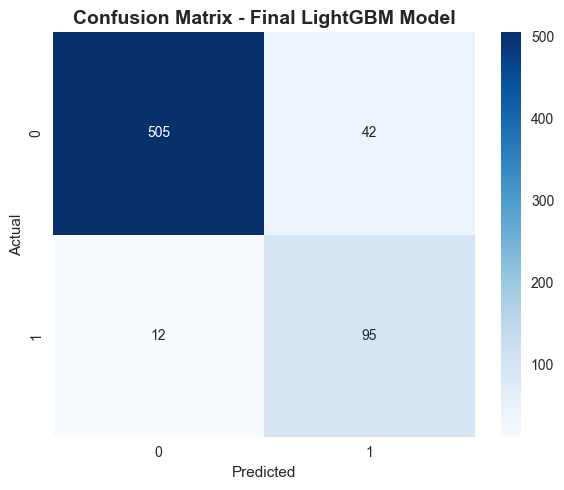

In [446]:
cm = confusion_matrix(y_test, y_pred, labels=[0,1])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True,  fmt='d',cmap='Blues')
plt.title('Confusion Matrix - Final LightGBM Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


## ROC Curve For Final Model

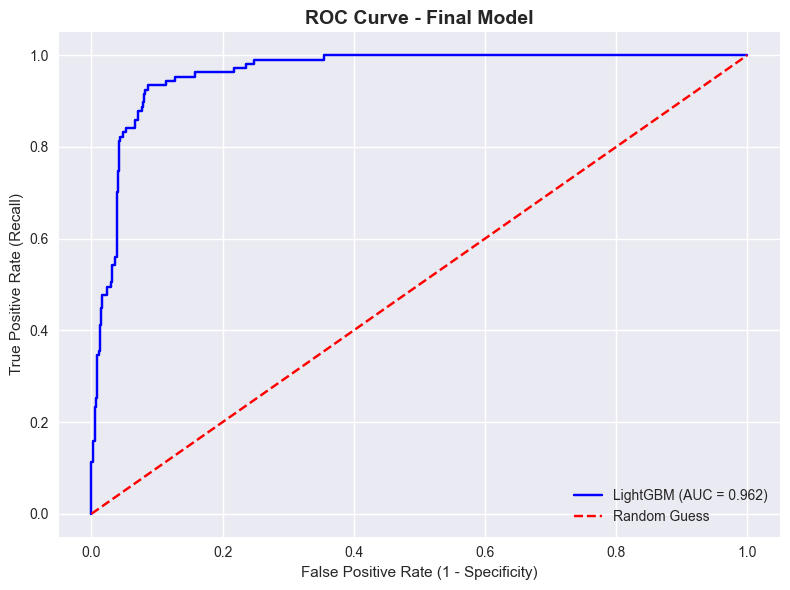

In [455]:
y_prob = final_model.predict_proba(X_test_preprocessed)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'LightGBM (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess') 

plt.title('ROC Curve - Final Model', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Precision-Recall Curve For Final Model

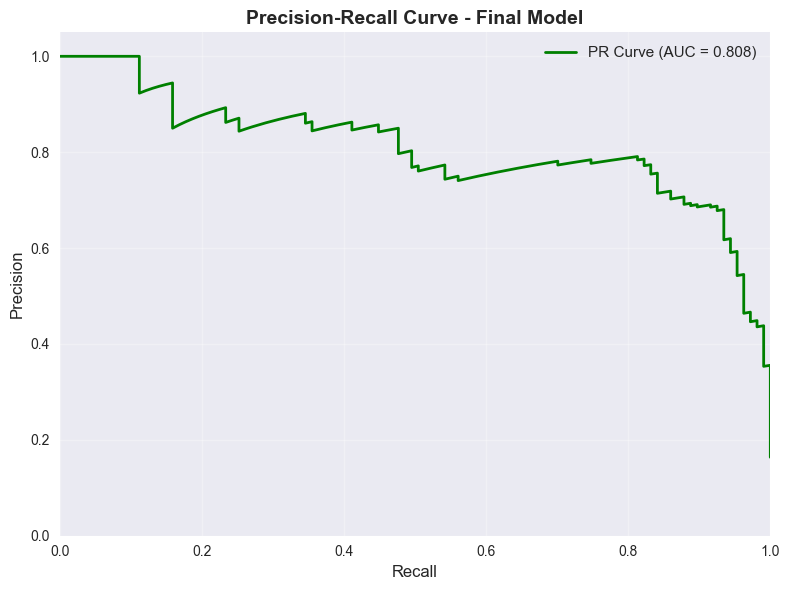

In [457]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='green', lw=2, 
         label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Final Model', fontsize=14, fontweight='bold')
plt.legend(loc="best", fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()


The final model achieves a **ROC–AUC score of 0.963**, indicating an excellent ability to distinguish between churn and non churn customers across all classification thresholds. This suggests strong overall separability and ranking performance.

The **Precision–Recall AUC score of 0.808** highlights the model’s effectiveness on the minority (churn) class. Given the class imbalance in the dataset, PR–AUC provides a more informative evaluation of how well the model balances precision and recall when identifying churners.

Overall, the high ROC–AUC combined with a strong PR–AUC confirms that the model not only separates classes well but also maintains reliable performance in detecting churn cases, which aligns with the project’s objective of prioritizing recall and F-beta optimization.


# Feature Importance from LightGBM

In [474]:
lgbm_model = final_model.named_steps['classfier']

feature_importance = lgbm_model.feature_importances_
feature_names = X_train_preprocessed.columns

importance_df = pd.DataFrame({
   'Feature Importance': feature_importance,
   'Feature Names': feature_names
})

importance_df.sort_values('Feature Importance', ascending=False)

,Feature Importance,Feature Names
7,1240,num__CashbackAmount
1,911,num__WarehouseToHome
0,663,num__Tenure
6,585,num__DaySinceLastOrder
4,377,num__NumberOfAddress
3,346,num__SatisfactionScore
2,261,num__NumberOfDeviceRegistered
5,116,num__Complain
15,111,cat__MaritalStatus_Single
14,68,cat__MaritalStatus_Married


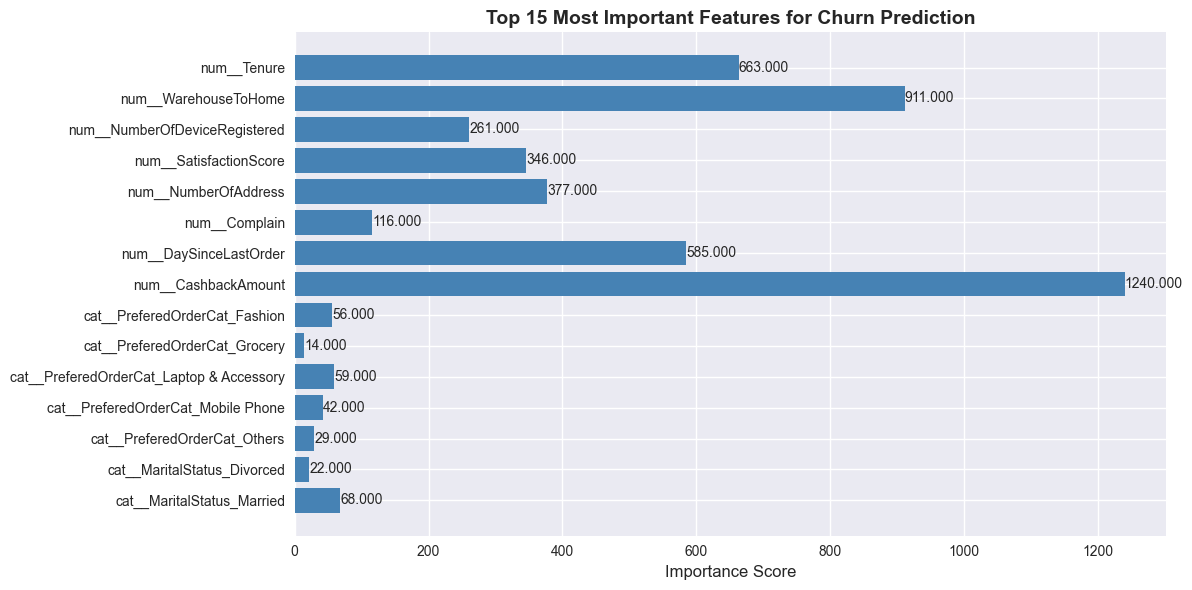

In [483]:
fig, ax = plt.subplots(figsize=(12, 6))

top_n = 15
top_features = importance_df.head(top_n)

bars = ax.barh(range(len(top_features)), top_features['Feature Importance'].values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature Names'].values)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Most Important Features for Churn Prediction', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, (feature, importance) in enumerate(zip(top_features['Feature Names'], top_features['Feature Importance'])):
    ax.text(importance + 0.005, i, f'{importance:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

- **CashbackAmount** is the most important feature, showing that incentives and rewards strongly affect churn.  
- **WarehouseToHome** and **Tenure** are also highly influential, meaning proximity to warehouses and customer loyalty matter.  
- **DaySinceLastOrder**, **NumberOfAddress**, and **SatisfactionScore** play moderate roles, reflecting recent activity and engagement.  
- **Complain** and **NumberOfDeviceRegistered** have smaller impact, indicating minor contributions.  
- **Categorical features** like **MaritalStatus** and **PreferredOrderCat** have relatively low importance, suggesting demographics and purchase category are secondary factors.

**Conclusion:** The model mainly relies on transactional and behavioral features to predict churn, while demographic information provides additional but less critical signals.


## Advanced Analysis With SHAP

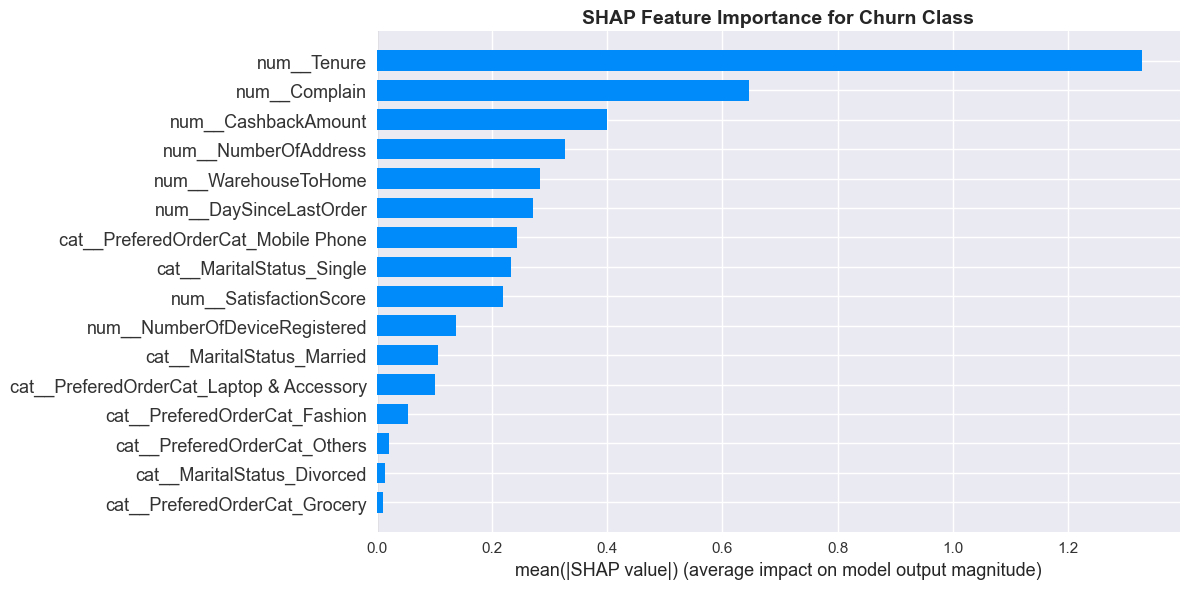

In [503]:
lgbm_model = final_model.named_steps['classfier']

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_preprocessed)

shap.summary_plot(shap_values, X_test_preprocessed, plot_type="bar", show=False, plot_size=(12, 6))
plt.title('SHAP Feature Importance for Churn Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

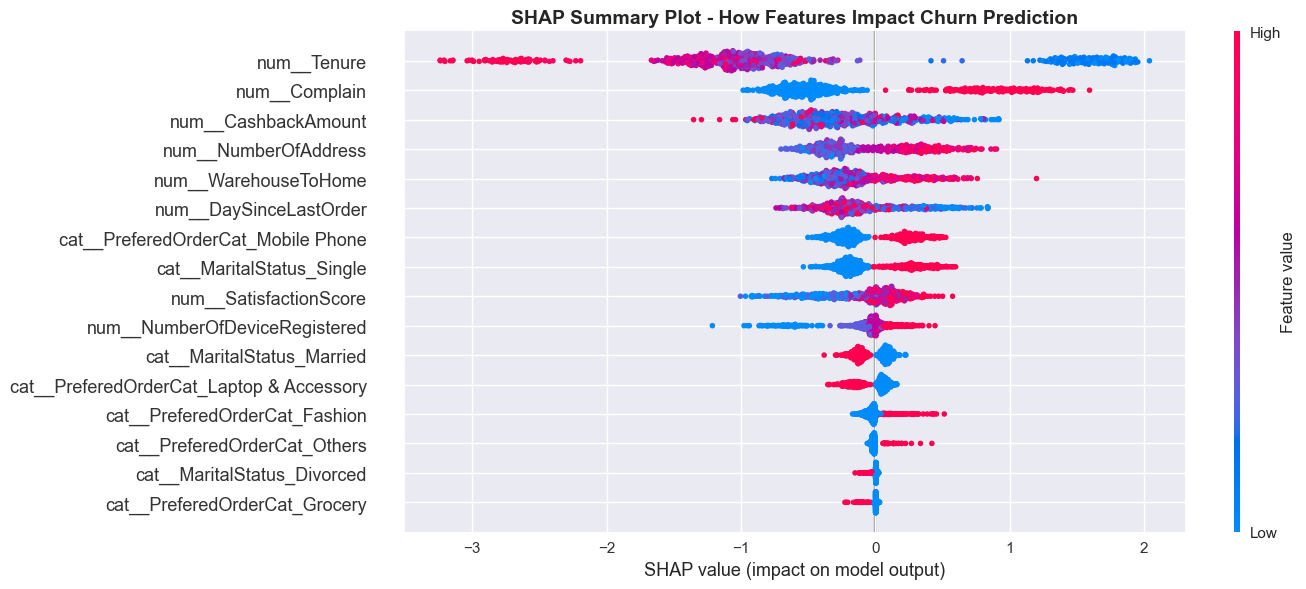

In [513]:
shap.summary_plot(shap_values, X_test_preprocessed, show=False,plot_size=(14, 6))
plt.title('SHAP Summary Plot - How Features Impact Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [523]:
shap_df = pd.DataFrame(
    shap_values,  
    columns=X_test_preprocessed.columns
)

print(shap_df.abs().mean().sort_values(ascending=False))

num__Tenure                                 1.328190
num__Complain                               0.646902
num__CashbackAmount                         0.398857
num__NumberOfAddress                        0.326905
num__WarehouseToHome                        0.282527
num__DaySinceLastOrder                      0.270313
cat__PreferedOrderCat_Mobile Phone          0.242948
cat__MaritalStatus_Single                   0.232343
num__SatisfactionScore                      0.218606
num__NumberOfDeviceRegistered               0.137452
cat__MaritalStatus_Married                  0.106748
cat__PreferedOrderCat_Laptop & Accessory    0.100354
cat__PreferedOrderCat_Fashion               0.054251
cat__PreferedOrderCat_Others                0.021606
cat__MaritalStatus_Divorced                 0.014113
cat__PreferedOrderCat_Grocery               0.011369
dtype: float64



### Key Insights
- **Tenure** is the strongest predictor: longer tenured customers are less likely to churn  
- **Customer complaints** significantly increase churn probability, addressing complaints quickly can help retain customers.  
- **Cashback incentives** and **efficient delivery (`WarehouseToHome`)** reduce churn, highlighting the importance of operational efficiency and loyalty programs.  
- Categorical features (like preferred order categories and marital status) have smaller impacts but still contribute to predictions.

### Why the Difference Between LightGBM and SHAP Feature Importance?
- **LightGBM native importance** measures how often a feature is used to split nodes in the trees. It captures **frequency and gain** but ignores the **direction of impact**.  
- **SHAP values** provide a **more interpretable, game theoretic view**:  
  - Show both **magnitude** and **direction** (whether a feature increases or decreases churn).  
  - Can highlight features that LightGBM importance may undervalue if they have consistent but subtle effects.  

> SHAP values offer deeper insights into **how and why features affect predictions**, while LightGBM importance is better for a quick ranking of influential features.
